In [1]:
log_dir = '../logs'

model_folders = ['combined_f_combined', 'combined_r_combined', 'combined_fx_combined']
epochs = [30]

root = '../data/'
views = ['f', 'r', 'fx']

In [4]:
import pickle
import os

i = 0
model_folder = model_folders[i]
epoch = epochs[i]
view = views[i]

gt_folders = [os.path.join(root, f'gt_ood_meadow_{view}_f'),
              os.path.join(root, f'gt_ood_forest_{view}_f'),
              os.path.join(root, f'gt_ood_desert_{view}_f'),
              os.path.join(root, f'gt_ood_industrial_{view}_f'),]
cams_path = os.path.join(log_dir, model_folder, 'activations', str(epoch), view, 'cams.pkl')
with open(cams_path, 'rb') as f:
    cams = pickle.load(f)

In [43]:
import cv2
import numpy as np
from PIL import Image

image_filename = '38c6d1391e2d41e390c9f8d8d0ec36dd_7_20240925194344.png'
cam = cams[image_filename]

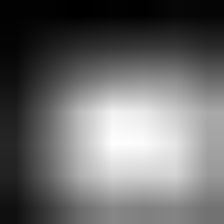

In [22]:
def find_gt_image(distorted_image_filename, gt_folders):
    for gt_folder in gt_folders:
        gt_image_path = os.path.join(gt_folder, distorted_image_filename)
        if os.path.exists(gt_image_path):
            return gt_image_path

    return None

In [23]:
gt_image_path = find_gt_image(image_filename, gt_folders)

In [34]:
from PIL import ImageFilter

gt_image = Image.open(gt_image_path)
alpha_channel = gt_image.split()[-1].convert('L')
alpha_channel = alpha_channel.resize((224, 224), Image.LANCZOS)

interior_mask = np.array(alpha_channel) > 128  # Object interior
exterior_mask = np.array(alpha_channel) <= 128  # Background (exterior)

# create a border mask by blurring the alpha mask and comparing the edges
blurred_alpha = alpha_channel.filter(ImageFilter.GaussianBlur(radius=1))
border_mask = np.logical_and(
    np.array(blurred_alpha) > 0, np.array(blurred_alpha) < 255
)  # border pixels

# remove border pixels from interior and exterior
interior_mask = np.logical_and(interior_mask, np.logical_not(border_mask))
exterior_mask = np.logical_and(exterior_mask, np.logical_not(border_mask))

In [45]:
cam = np.squeeze(cam)
cam

array([[0.00965675, 0.00965675, 0.00965675, ..., 0.02150276, 0.02150276,
        0.02150276],
       [0.00965675, 0.00965675, 0.00965675, ..., 0.02150276, 0.02150276,
        0.02150276],
       [0.00965675, 0.00965675, 0.00965675, ..., 0.02150276, 0.02150276,
        0.02150276],
       ...,
       [0.06168771, 0.06168771, 0.06168771, ..., 0.44730332, 0.44730332,
        0.44730332],
       [0.06168771, 0.06168771, 0.06168771, ..., 0.44730332, 0.44730332,
        0.44730332],
       [0.06168771, 0.06168771, 0.06168771, ..., 0.44730332, 0.44730332,
        0.44730332]], dtype=float32)

In [49]:
cam_interior = np.multiply(interior_mask, cam)

In [50]:
cam_interior.shape

(224, 224)

In [63]:
# cam_interior = cam[interior_mask]
# cam_border = cam[border_mask]
# cam_exterior = cam[exterior_mask]

cam_interior = np.multiply(interior_mask, cam)
cam_border = np.multiply(border_mask, cam)
cam_exterior = np.multiply(exterior_mask, cam)

cam = np.uint8(225*cam)
cam_interior = np.uint8(255*cam_interior)
cam_border = np.uint8(255*cam_border)
cam_exterior = np.uint8(255*cam_exterior)

cam = cv2.merge([cam, cam, cam])
cam_interior = cv2.merge([cam_interior, cam_interior, cam_interior])
cam_border = cv2.merge([cam_border, cam_border, cam_border])
cam_exterior = cv2.merge([cam_exterior, cam_exterior, cam_exterior])

In [64]:
cam_interior.shape

(224, 224, 3)

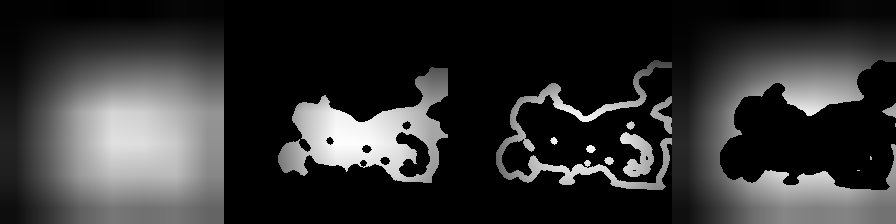

In [65]:
all_cams = np.hstack((cam, cam_interior, cam_border, cam_exterior))
Image.fromarray(all_cams)

In [27]:
interior_cam_values = cam[interior_mask].flatten()
exterior_cam_values = cam[exterior_mask].flatten()
border_cam_values = cam[border_mask].flatten()

In [28]:
interior_mean = np.mean(interior_cam_values)
border_mean = np.mean(border_cam_values)
exterior_mean = np.mean(exterior_cam_values)

In [67]:
cam_interior_values = cam_interior.flatten()
cam_interior_values.shape

(150528,)